# Imports

In [1]:
# Instalar PyTorch con CUDA (primero, para evitar que sentence-transformers instale CPU)
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Core libs
%pip install pandas==2.2.2 matplotlib==3.9.0 \
datasets==2.20.0 pyarrow==15.0.2 \
lime==0.2.0.1 shap==0.45.1

  Using cached pandas-2.2.2.tar.gz (4.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      + meson setup C:\Users\Usuario\AppData\Local\Temp\pip-install-j1zc7owv\pandas_b1f60701614b401a922d18745d98fd07 C:\Users\Usuario\AppData\Local\Temp\pip-install-j1zc7owv\pandas_b1f60701614b401a922d18745d98fd07\.mesonpy-k456jw6b\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\Usuario\AppData\Local\Temp\pip-install-j1zc7owv\pandas_b1f60701614b401a922d18745d98fd07\.mesonpy-k456jw6b\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\Usuario\AppData\Local\Temp\pip-install-j1zc7owv\pandas_b1f60701614b401a922d18745d98fd07
      Build dir: C:\Users\Usuario\AppData\Local\Temp\pip-install-j1zc7owv\pandas_b1f60701614b401a922d18745d98fd07\.mesonpy-k456jw6b\build
      Build type: native build
      Project name: pandas
      Project version: 

In [3]:
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import gc
import pandas as pd

from datasets import load_dataset
from datasets import Dataset

import torch
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# IMDB dataset

In [5]:
dataset = load_dataset("imdb")
df_text_train = pd.DataFrame(dataset["train"])
df_text_test = pd.DataFrame(dataset["test"])

In [6]:
column_nan_count = df_text_train.isnull().sum()
print("NaN count per column:")
print(column_nan_count)

column_nan_count = df_text_test.isnull().sum()
print("NaN count per column:")
print(column_nan_count)

NaN count per column:
text     0
label    0
dtype: int64
NaN count per column:
text     0
label    0
dtype: int64


In [7]:
X_text_train = df_text_train["text"]
y_text_train = df_text_train["label"]

X_text_test = df_text_test["text"]
y_text_test = df_text_test["label"]

print(X_text_train.head())
print(y_text_train.head())

print(X_text_test.head())
print(y_text_test.head())

0    I rented I AM CURIOUS-YELLOW from my video sto...
1    "I Am Curious: Yellow" is a risible and preten...
2    If only to avoid making this type of film in t...
3    This film was probably inspired by Godard's Ma...
4    Oh, brother...after hearing about this ridicul...
Name: text, dtype: str
0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64
0    I love sci-fi and am willing to put up with a ...
1    Worth the entertainment value of a rental, esp...
2    its a totally average film with a few semi-alr...
3    STAR RATING: ***** Saturday Night **** Friday ...
4    First off let me say, If you haven't enjoyed a...
Name: text, dtype: str
0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


# Preprocessing

In [8]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_MODEL_LENGTH = 2048
MAX_LENGTH = 2048

In [9]:
def build_prompt(review):

    prompt = f"""Review: {review}

Sentiment:"""

    return prompt


def build_full_text(review, label):

    sentiment = (
        "positive"
        if label == 1
        else "negative"
    )

    full_text = f"""Review: {review}

Sentiment: {sentiment}"""

    return full_text


def preprocess_dataset(dataset, tokenizer):

    input_ids_list = []
    attention_masks_list = []
    labels_list = []
    true_labels_list = []

    for example in dataset:

        review = example["text"]
        label = example["label"]

        prompt = build_prompt(review)
        full_text = build_full_text(review, label)

        # =========================
        # TOKENIZACIÓN
        # =========================

        full = tokenizer(
            full_text,
            add_special_tokens=False
        )

        input_ids = full["input_ids"]

        # attention mask inicial
        attention_mask = [1] * len(input_ids)

        # =========================
        # LABELS (SIN prompt_len)
        # =========================

        labels = []

        # reconstruimos prompt tokenizado directamente dentro del full_text
        prompt_text = build_prompt(review)

        prompt_ids = tokenizer(
            prompt_text,
            add_special_tokens=False
        )["input_ids"]

        # ⚠️ no asumimos alineación por slicing, buscamos corte seguro por longitud
        prompt_len = len(prompt_ids)

        for i, tok in enumerate(input_ids):

            if i < prompt_len:
                labels.append(-100)
            else:
                labels.append(tok)

        # =========================
        # PADDING / TRUNCATION UNIFORME
        # =========================

        if len(input_ids) > MAX_LENGTH:

            input_ids = input_ids[:MAX_LENGTH]
            attention_mask = attention_mask[:MAX_LENGTH]
            labels = labels[:MAX_LENGTH]

        else:

            pad_len = MAX_LENGTH - len(input_ids)

            input_ids += [tokenizer.pad_token_id] * pad_len
            attention_mask += [0] * pad_len
            labels += [-100] * pad_len

        # =========================
        # TRUE LABEL EXPLÍCITO
        # =========================

        true_label = "positive" if label == 1 else "negative"

        # =========================
        # STORE
        # =========================

        input_ids_list.append(input_ids)
        attention_masks_list.append(attention_mask)
        labels_list.append(labels)
        true_labels_list.append(true_label)

    return Dataset.from_dict({
        "input_ids": input_ids_list,
        "attention_mask": attention_masks_list,
        "labels": labels_list,
        "true_label": true_labels_list
    })

In [10]:
# Model tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [11]:
tokenizer.vocab_size

32000

In [12]:
# Check positive token decomposition
tokenizer.tokenize("positive")

['▁positive']

In [13]:
# Check negative token decomposition
tokenizer.tokenize("negative")

['▁negative']

In [14]:
def fits_model(example):

    text = build_full_text(
        example["text"],
        example["label"]
    )

    tokens = tokenizer(
        text,
        add_special_tokens=True
    )["input_ids"]

    return len(tokens) <= MAX_MODEL_LENGTH

In [15]:
split = dataset["train"].train_test_split(
    test_size=0.1,
    seed=42
)

train_raw = split["train"]
val_raw = split["test"]
test_raw = dataset["test"]

In [16]:
# Reviews exceeding model context are removed from the dataset.

filtered_train = train_raw.filter(
    fits_model
)

filtered_val = val_raw.filter(
    fits_model
)

filtered_test = test_raw.filter(
    fits_model
)

In [17]:
print(len(filtered_train))
print(len(filtered_val))
print(len(filtered_test))

22492
2500
24995


In [18]:
train_dataset = preprocess_dataset(filtered_train, tokenizer)
val_dataset = preprocess_dataset(filtered_val, tokenizer)
test_dataset = preprocess_dataset(filtered_test, tokenizer)

In [19]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

val_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

# Model fine-tuning

In [20]:
# LLM Model download
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11925.24it/s]


In [21]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [22]:
teacher_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [23]:
BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [24]:
EPOCHS = 1

In [25]:
import os
os.makedirs("./checkpoints", exist_ok=True)

In [26]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(
    log_dir="./runs/tinyllama_imdb"
)

In [27]:
optimizer = torch.optim.AdamW(
    teacher_model.parameters(),
    lr=2e-5
)

In [28]:
# EARLY STOPPING
best_val_loss = float("inf")
patience = 5
patience_counter = 0
eval_every = 1000
save_every = 2000
start_epoch = 0
global_step = 0
max_val_steps = 100

In [29]:
def save_checkpoint(model, optimizer, epoch, global_step, path="checkpoint.pt"):

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "global_step": global_step
        },
        path
    )

def load_checkpoint(model, optimizer, path="checkpoint.pt"):

    ckpt = torch.load(path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    return ckpt["epoch"], ckpt["global_step"]

In [ ]:
try:
    start_epoch, global_step = load_checkpoint(
        teacher_model,
        optimizer,
        "checkpoints/teacher_checkpoint.pt"
    )
    print(f"[RESUME] Epoch {start_epoch} | Global step {global_step}")

except:
    print("[START] Training from scratch")

# =========================
# INIT LOSS (ANTES DEL TRAIN LOOP)
# =========================

teacher_model.eval()

with torch.no_grad():
    batch = next(iter(train_loader))

    init_outputs = teacher_model(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        labels=batch["labels"].to(device)
    )

    print(f"[INIT LOSS] {init_outputs.loss.item():.4f}")

teacher_model.train()

# =========================
# TRAINING
# =========================

for epoch in range(start_epoch, EPOCHS):

    teacher_model.train()
    total_loss = 0

    for step, batch in enumerate(train_loader):

        global_step += 1

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = teacher_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        writer.add_scalar("Loss/train", loss.item(), global_step)

        if global_step % 50 == 0:
            avg_loss = total_loss / (step + 1)

            print(
                f"Epoch {epoch} | "
                f"Step {step} | "
                f"Global {global_step} | "
                f"Loss {avg_loss:.4f}"
            )

        # =========================
        # VALIDATION
        # =========================

        if global_step % eval_every == 0:

            teacher_model.eval()

            val_loss = 0
            val_steps = 0

            with torch.no_grad():
                for val_batch in val_loader:

                    val_steps += 1

                    val_outputs = teacher_model(
                        input_ids=val_batch["input_ids"].to(device),
                        attention_mask=val_batch["attention_mask"].to(device),
                        labels=val_batch["labels"].to(device)
                    )

                    val_loss += val_outputs.loss.item()

                    if val_steps >= max_val_steps:
                        break

            val_loss /= val_steps

            writer.add_scalar("Loss/validation", val_loss, global_step)

            print(f"\n[VAL LOSS] {val_loss:.4f}\n")

            # =========================
            # BEST MODEL
            # =========================

            if val_loss < best_val_loss:

                best_val_loss = val_loss
                patience_counter = 0

                torch.save(
                    teacher_model.state_dict(),
                    ".checkpoints/best_teacher_model.pt"
                )

                print("[BEST MODEL SAVED]")

            else:
                patience_counter += 1

            # =========================
            # CHECKPOINT
            # =========================

            save_checkpoint(
                teacher_model,
                optimizer,
                epoch,
                global_step,
                "checkpoints/teacher_checkpoint.pt"
            )

            # =========================
            # EARLY STOP
            # =========================

            if patience_counter >= patience:
                print("[EARLY STOP]")
                writer.flush()
                break

            teacher_model.train()

        # =========================
        # CLEANUP
        # =========================

        del input_ids, attention_mask, labels, outputs, loss

    gc.collect()

    if patience_counter >= patience:
        break

writer.flush()

[START] Training from scratch
[INIT LOSS] 9.1793
Epoch 0 | Step 49 | Global 50 | Loss 0.7593
Epoch 0 | Step 99 | Global 100 | Loss 0.4606
Epoch 0 | Step 149 | Global 150 | Loss 0.4691
Epoch 0 | Step 199 | Global 200 | Loss 0.4568
Epoch 0 | Step 249 | Global 250 | Loss 0.4060
Epoch 0 | Step 299 | Global 300 | Loss 0.3768
Epoch 0 | Step 349 | Global 350 | Loss 0.3418
Epoch 0 | Step 399 | Global 400 | Loss 0.3182
Epoch 0 | Step 449 | Global 450 | Loss 0.3289
Epoch 0 | Step 499 | Global 500 | Loss 0.3095
Epoch 0 | Step 549 | Global 550 | Loss 0.3262
Epoch 0 | Step 599 | Global 600 | Loss 0.3111
Epoch 0 | Step 649 | Global 650 | Loss 0.2963
Epoch 0 | Step 699 | Global 700 | Loss 0.2781
Epoch 0 | Step 749 | Global 750 | Loss 0.2646
Epoch 0 | Step 799 | Global 800 | Loss 0.2861
Epoch 0 | Step 849 | Global 850 | Loss 0.3049
Epoch 0 | Step 899 | Global 900 | Loss 0.3038
Epoch 0 | Step 949 | Global 950 | Loss 0.3089
Epoch 0 | Step 999 | Global 1000 | Loss 0.3135

[VAL LOSS] 0.2651

[BEST MODEL S

# Test teacher

In [32]:
teacher_model.load_state_dict(
    torch.load(
        "./checkpoints/best_teacher_model.pt",
        map_location=device
    )
)

<All keys matched successfully>

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =========================
# TARGET TOKENS
# =========================

positive_id = tokenizer.encode(
    " positive",
    add_special_tokens=False
)[0]

negative_id = tokenizer.encode(
    " negative",
    add_special_tokens=False
)[0]

# =========================
# TEST EVALUATION
# =========================

teacher_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        true_labels = batch["true_label"]

        outputs = teacher_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        last_idx = attention_mask.sum(dim=1) - 1

        logits = outputs.logits[
            torch.arange(input_ids.size(0), device=device),
            last_idx
        ]

        positive_logits = logits[:, positive_id]
        negative_logits = logits[:, negative_id]

        preds = positive_logits > negative_logits

        for p, t in zip(preds, true_labels):

            y_pred.append(
                "positive" if p.item() else "negative"
            )

            y_true.append(t)

# =========================
# METRICS
# =========================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "positive",
        "negative"
    ]
)

In [42]:
# =========================
# PRINT
# =========================

print("\n=========================")
print("[TEST RESULTS]")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print("=========================\n")

print("[CONFUSION MATRIX]")
print(cm)


[TEST RESULTS]
Accuracy : 0.9681
Precision: 0.9681
Recall   : 0.9681
F1 Score : 0.9681

[CONFUSION MATRIX]
[[12059   436]
 [  362 12138]]


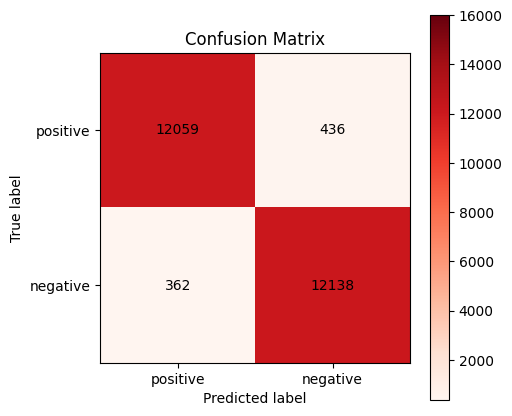

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(cm, cmap="Reds", vmax=16000)

# labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["positive", "negative"])
ax.set_yticklabels(["positive", "negative"])

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

# valores dentro de las celdas
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="black")

plt.colorbar(im)
plt.show()

In [39]:
# =========================
# TENSORBOARD
# =========================

writer.add_scalar(
    "Test/accuracy",
    test_accuracy,
    global_step
)

writer.add_scalar(
    "Test/precision",
    test_precision,
    global_step
)

writer.add_scalar(
    "Test/recall",
    test_recall,
    global_step
)

writer.add_scalar(
    "Test/f1",
    test_f1,
    global_step
)

writer.close()